<a href="https://colab.research.google.com/github/Ganzer13/data-science-2026/blob/main/pertemuan7_roland_240401010294.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = 3.0 + 2.2 * pengalaman + 1.5 * edu + np.where(kota == 'Jakarta', 4.0, 0) + np.random.normal(0, 2, n)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

display(df.head())
display(df.info())
display(df.describe())

,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pengalaman  300 non-null    float64
 1   edu         300 non-null    int64  
 2   kota        300 non-null    object 
 3   gaji        300 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 9.5+ KB


None

,pengalaman,edu,gaji
count,300.000000,300.000000,300.000000
mean,9.904092,0.886667,27.401294
std,5.886811,0.826296,13.406371
min,0.101232,0.000000,1.672200
25%,4.781616,0.000000,16.242495
50%,10.234355,1.000000,27.974936
75%,15.137192,2.000000,38.894143
max,19.801077,2.000000,54.223931


In [2]:
print("Jumlah Missing Value per kolom:")
print(df.isnull().sum())

Jumlah Missing Value per kolom:
pengalaman    0
edu           0
kota          0
gaji          0
dtype: int64


In [3]:
df_encoded = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)

display(df_encoded.head())

,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


In [4]:
from sklearn.model_selection import train_test_split

x = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Dimensi x_train: {x_train.shape}")
print(f"Dimensi x_test: {x_test.shape}")

Dimensi x_train: (240, 4)
Dimensi x_test: (60, 4)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

=== Hasil Evaluasi Model ===
MAE  = 1.649
RMSE = 2.123
R2   = 0.9740


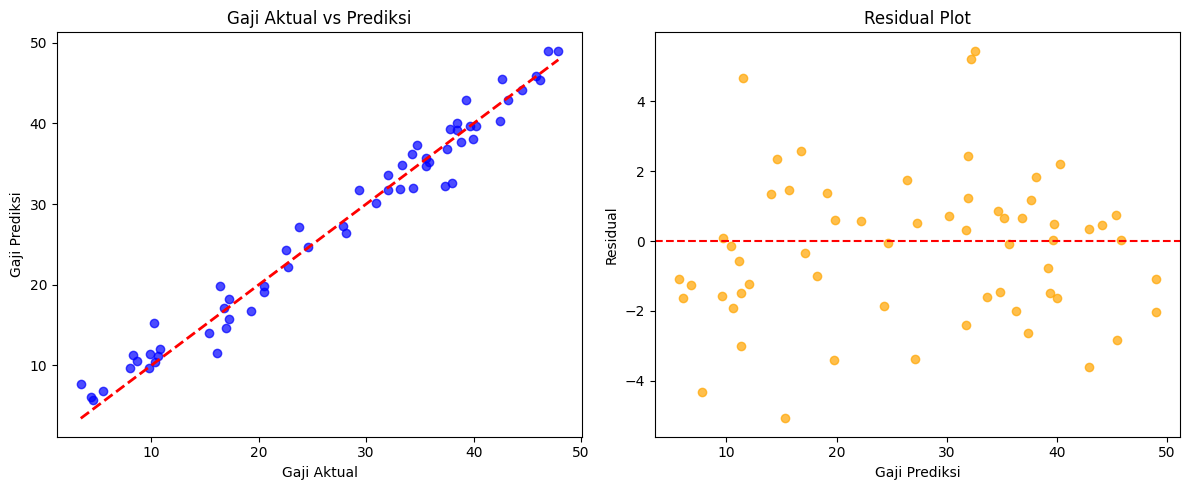

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

model = LinearRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Hasil Evaluasi Model ===")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R2   = {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.7, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Gaji Aktual')
axes[0].set_ylabel('Gaji Prediksi')
axes[0].set_title('Gaji Aktual vs Prediksi')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.7, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Gaji Prediksi')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
